# Risk Decomposition via PCA

## Purpose

The backtest in the previous notebook tells us whether the strategy makes money. This notebook will tell us where its risk comes from. 

Portfolio risk is the quadratic form
$$ \langle \Sigma w, w \rangle = w^T \Sigma w $$
where $\Sigma$ is the $N \times N$ covariance matrix and $w$ is our vector of weights. We use the eigendecomposition of $\Sigma$ to split the quadratic form into systematic (factor-driven) and idiosyncratic (stock-specific) components.

The main goals are the following.
1. To compute the sample covariance matrix $\Sigma = \frac{1}{T-1}X_c^T X_c$.
2. To use PCA on $\Sigma$ using `sklearn.decomposition.PCA` (which is really an eigendecomposition $\Sigma = V\Lambda V^T$ under the hood).
3. To apply the Marchenko-Pastur cutoff from random matrix theory to separate signal eigenvalues from noise.
4. To implement Ledoit-Wolf shrinkage (a convex combination of sample and structured covariance) and show it improves out-of-sample estimation.
5. To decompose the portfolio's variance $\langle \Sigma w, w \rangle$ into the factor subspace and its orthogonal complement. 

### Terms used in this notebook

| Term | Meaning |
|------|---------|
| **Covariance matrix** $\Sigma$ | $N \times N$ symmetric PSD matrix; $\Sigma_{ij} = \mathrm{Cov}(r_i, r_j)$ |
| **PCA (principal component analysis)** | Eigendecomposition of $\Sigma$; eigenvectors = principal components, eigenvalues = explained variances |
| **Scree plot** | Eigenvalues in decreasing order — visualizes the spectrum |
| **Marchenko–Pastur distribution** | Limiting eigenvalue law of a random covariance matrix; gives an objective noise cutoff |
| **Shrinkage estimator** | $\hat\Sigma = \delta \mathbf{F} + (1-\delta)\mathbf{S}$ — convex combination of sample $\mathbf{S}$ and structured target $\mathbf{F}$ |
| **Risk model** | Low-rank + diagonal split $\Sigma \approx B\Sigma_f B^\top + D$ |
| **Systematic risk** | Variance explained by common factors (the low-rank part $B\Sigma_f B^\top$) |
| **Idiosyncratic risk** | Stock-specific variance (the diagonal part $D$) |
| **Portfolio variance** | The quadratic form $w^\top \Sigma w$ being decomposed |
| **Beta** ↻ | Factor loadings reappear as the coordinates $B$ |
| **Portfolio weights** ↻ | The weight vector $w$ whose risk $w^\top \Sigma w$ we decompose |

## Outputs

Eigenvalue spectrum with Marchenko–Pastur overlay, Ledoit–Wolf shrinkage comparison, and a portfolio variance decomposition table.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Load Data](#load-data)
3. [Sample Covariance and PCA](#sample-covariance-and-pca)
4. [Marchenko–Pastur Noise Separation](#marchenkopastur-noise-separation)
5. [Ledoit–Wolf Shrinkage](#ledoitwolf-shrinkage)
6. [Portfolio Variance Decomposition](#portfolio-variance-decomposition)
7. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/05_risk_decomposition', exist_ok=True)

RANDOM_STATE = 3

In [2]:
"""
==================================
Load returns and backtest holdings
==================================
"""
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_backtest = pd.read_csv('../data/processed/backtest_returns.csv', index_col=0, parse_dates=True)

print(f"Returns:   {df_returns.shape}")
print(f"Backtest:  {df_backtest.shape}")

Returns:   (251, 501)
Backtest:  (239, 5)


## Sample Covariance and PCA

Given the centered return matrix $\mathbf{X}_c \in \mathbb{R}^{T \times N}$ (each row demeaned), the **sample covariance matrix** is:

$$\Sigma = \frac{1}{T-1} \mathbf{X}_c^\top \mathbf{X}_c.$$

This is an $N \times N$ symmetric positive-semidefinite matrix. **PCA** is its eigendecomposition:

$$\Sigma = \mathbf{V} \Lambda \mathbf{V}^\top, \quad \Lambda = \text{diag}(\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_N).$$

The columns of $\mathbf{V}$ are the **principal components** (directions of maximum variance, in decreasing order); the eigenvalues $\lambda_i$ are the **explained variances**.

Under the hood, `sklearn.decomposition.PCA` computes this via SVD of $\mathbf{X}_c = \mathbf{U}\mathbf{S}\mathbf{V}^\top$, which gives $\Sigma = \frac{1}{T-1}\mathbf{V}\mathbf{S}^2\mathbf{V}^\top$ with eigenvalues $\lambda_i = s_i^2/(T-1)$. We delegate the numerics to sklearn and keep the eigenvalues/eigenvectors for the Marchenko–Pastur and variance decomposition analyses below.

In [3]:
"""
==================================
PCA via sklearn
==================================
"""
# Use a balanced panel: keep stocks present for most of the sample, then use
# the months where all of them coexist. thresh must be high — a low thresh admits
# short-history stocks, and the chained dropna() then truncates EVERY stock to that
# short window (e.g. thresh=60 collapses the panel to 60 months, leaving N >> T and a
# rank-deficient covariance). Maximizing observations matters most here.
valid = df_returns.dropna(thresh=240, axis=1).dropna()
X = valid.values
X_centered = X - X.mean(axis=0)

n_obs, n_assets = X_centered.shape

# Sample covariance
cov = np.cov(X_centered, rowvar=False, ddof=1)

# sklearn PCA — fits on the centered data
pca = PCA()
pca.fit(X_centered)

# Build the same result dict so downstream cells are unchanged
pca_result = {
    'eigenvalues': pca.explained_variance_,
    'eigenvectors': pca.components_.T,   # sklearn returns (k x N); we want (N x k)
    'explained_ratio': pca.explained_variance_ratio_,
    'tickers': valid.columns.tolist(),
    'n_obs': n_obs,
    'n_assets': n_assets,
    'cov': cov,
}

print(f"Number of assets: {pca_result['n_assets']}")
print(f"Number of observations: {pca_result['n_obs']}")
print(f"\nTop 10 eigenvalues:")
for i, ev in enumerate(pca_result['eigenvalues'][:10]):
    print(f"  PC{i+1}: {ev:.6f}  ({pca_result['explained_ratio'][i]*100:.2f}%)")

Number of assets: 394
Number of observations: 240

Top 10 eigenvalues:
  PC1: 1.048239  (34.10%)
  PC2: 0.112295  (3.65%)
  PC3: 0.104251  (3.39%)
  PC4: 0.092663  (3.01%)
  PC5: 0.071925  (2.34%)
  PC6: 0.057767  (1.88%)
  PC7: 0.053078  (1.73%)
  PC8: 0.047010  (1.53%)
  PC9: 0.041681  (1.36%)
  PC10: 0.040488  (1.32%)


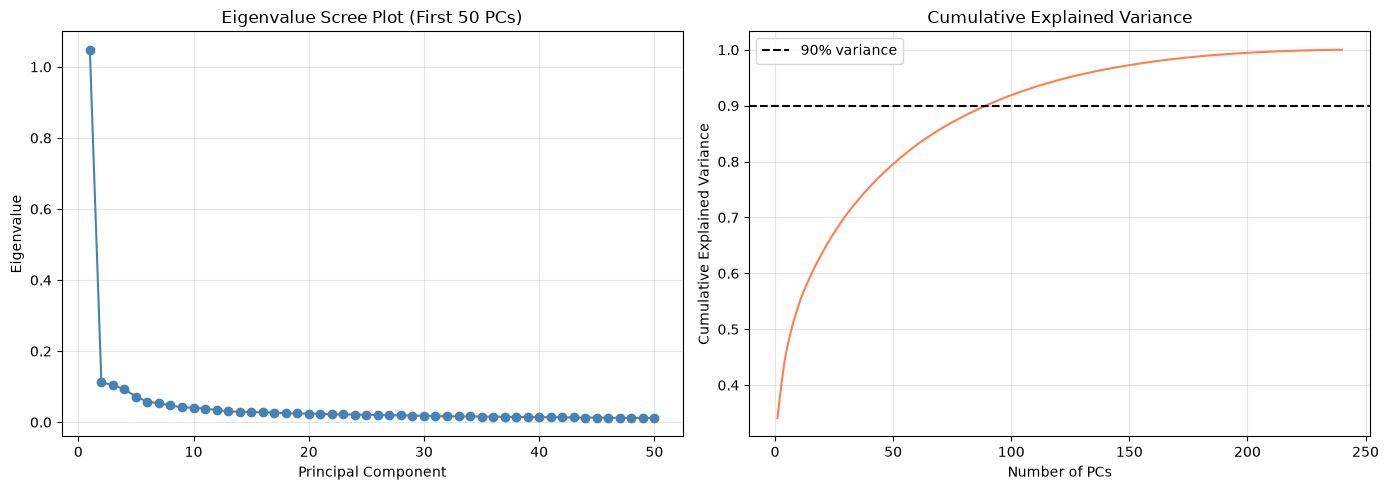

PCs needed for 90% variance: 90


In [4]:
"""
==================================
Eigenvalue scree plot
==================================
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (first 50 PCs)
ax = axes[0]
n_show = 50
ax.plot(range(1, n_show+1), pca_result['eigenvalues'][:n_show], 'o-', color='steelblue')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Scree Plot (First 50 PCs)')
ax.grid(alpha=0.3)

# Cumulative explained variance
ax = axes[1]
cum_var = np.cumsum(pca_result['explained_ratio'])
ax.plot(range(1, len(cum_var)+1), cum_var, color='coral')
ax.axhline(y=0.9, color='black', linestyle='--', label='90% variance')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

# How many PCs for 90% variance?
n_90 = np.searchsorted(cum_var, 0.9) + 1
print(f"PCs needed for 90% variance: {n_90}")

## Marchenko–Pastur Noise Separation

**Random matrix theory** gives us an objective cutoff for how many principal components are signal vs. noise.

For an $N \times T$ matrix $\mathbf{W}$ of iid random variables with variance $\sigma^2$, the eigenvalues of the sample covariance $\frac{1}{T}\mathbf{W}^\top \mathbf{W}$ converge (as $N, T \to \infty$ with ratio $q = T/N$ fixed) to the **Marchenko–Pastur distribution** with support:

$$\lambda_{\pm} = \sigma^2 \left(1 + \frac{1}{q} \pm 2\sqrt{\frac{1}{q}}\right), \quad q = T/N.$$

Eigenvalues falling inside $[\lambda_-, \lambda_+]$ are **consistent with noise** — they're what you'd get from a random matrix with no true factor structure. Eigenvalues **above** $\lambda_+$ are statistically significant factors. This gives us a distribution-theoretic cutoff for how many components to retain, rather than an ad-hoc scree-plot eyeball.

q = T/N = 0.6091
sigma^2 (scale): 0.007802
MP bounds: [0.000617, 0.040603]
Number of signal eigenvalues (above MP upper bound): 9


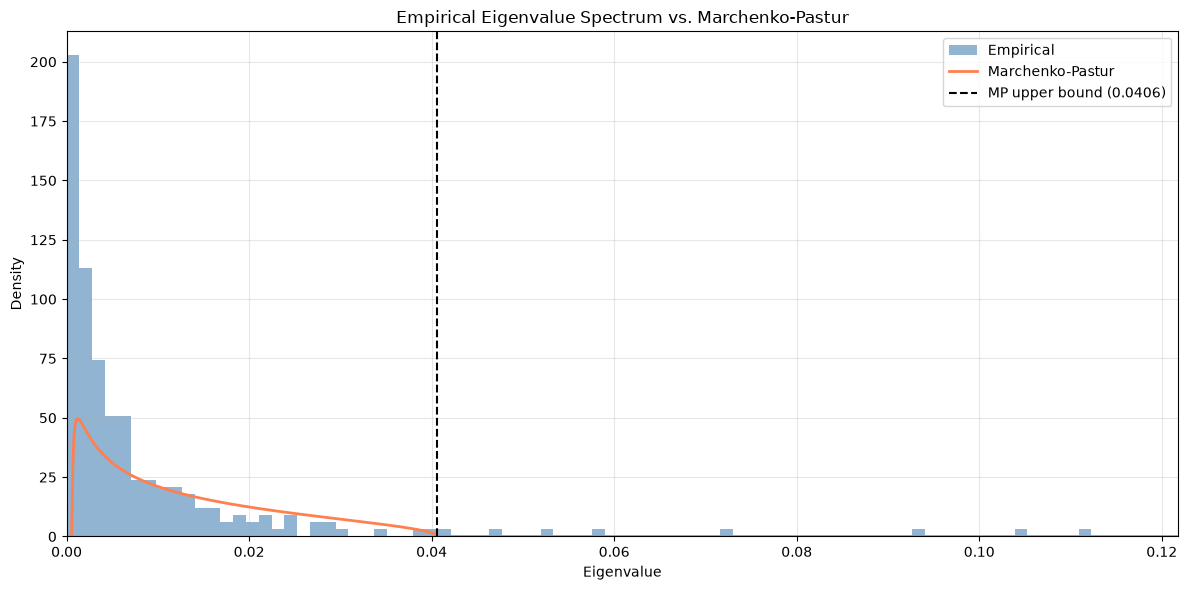

In [5]:
"""
==================================
Marchenko-Pastur cutoff
==================================
"""
def marchenko_pastur_bounds(q, sigma_sq=1.0):
    """Compute MP upper and lower bounds."""
    inv_q = 1 / q
    lambda_plus = sigma_sq * (1 + inv_q + 2 * np.sqrt(inv_q))
    lambda_minus = sigma_sq * (1 + inv_q - 2 * np.sqrt(inv_q))
    return lambda_minus, lambda_plus

def mp_density(x, q, sigma_sq=1.0):
    """Marchenko-Pastur probability density."""
    lam_minus, lam_plus = marchenko_pastur_bounds(q, sigma_sq)
    mask = (x > lam_minus) & (x < lam_plus)
    density = np.zeros_like(x)
    density[mask] = (q / (2 * np.pi * sigma_sq * x[mask])) * \
                    np.sqrt((lam_plus - x[mask]) * (x[mask] - lam_minus))
    return density

# Compute MP parameters
T = pca_result['n_obs']
N = pca_result['n_assets']
q = T / N

# Scale sigma^2 to match the bulk of the empirical spectrum
# Estimate sigma^2 as the mean eigenvalue (equals average variance of stocks)
# Under the null of pure noise, MP distribution mean = sigma^2
# NOTE: this overestimates sigma^2 because signal eigenvalues pull the mean up,
# making the MP cutoff conservative (fewer false-positive factors).  A more
# rigorous estimate would fit sigma^2 from the noise-only portion of the spectrum
# (e.g. the median of eigenvalues below a preliminary threshold).
# sigma^2 = trace(Sigma) / N = sum of all eigenvalues / N
# (sklearn returns only min(T,N) eigenvalues, so divide by N, not len(eigenvalues))
sigma_sq = np.sum(pca_result['eigenvalues']) / pca_result['n_assets']

lam_minus, lam_plus = marchenko_pastur_bounds(q, sigma_sq)
n_signal = np.sum(pca_result['eigenvalues'] > lam_plus)

print(f"q = T/N = {q:.4f}")
print(f"sigma^2 (scale): {sigma_sq:.6f}")
print(f"MP bounds: [{lam_minus:.6f}, {lam_plus:.6f}]")
print(f"Number of signal eigenvalues (above MP upper bound): {n_signal}")

# Plot empirical vs MP
fig, ax = plt.subplots(figsize=(12, 6))

eigs = pca_result['eigenvalues']
eigs_bulk = eigs[eigs < lam_plus * 5]  # Show bulk, exclude extreme top

ax.hist(eigs_bulk, bins=80, density=True, color='steelblue', alpha=0.6, label='Empirical')

x = np.linspace(max(0, lam_minus * 0.5), lam_plus * 3, 1000)
ax.plot(x, mp_density(x, q, sigma_sq), color='coral', linewidth=2, label='Marchenko-Pastur')
ax.axvline(x=lam_plus, color='black', linestyle='--', label=f'MP upper bound ({lam_plus:.4f})')

ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical Eigenvalue Spectrum vs. Marchenko-Pastur')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, lam_plus * 3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/marchenko_pastur.png', dpi=150, bbox_inches='tight')
plt.show()

## Ledoit–Wolf Shrinkage

The sample covariance $\mathbf{S} = \frac{1}{T-1}\mathbf{X}_c^\top \mathbf{X}_c$ is a noisy estimator when $N$ is large relative to $T$ — many eigenvalues are inflated or deflated by sampling noise (as the Marchenko–Pastur analysis shows).

**Ledoit–Wolf shrinkage** forms a convex combination:

$$\hat\Sigma = \delta \mathbf{F} + (1-\delta) \mathbf{S}, \quad \delta \in [0, 1],$$

where $\mathbf{F}$ is a structured target (here, the constant-correlation matrix) and $\delta$ is chosen to minimize $\mathbb{E}\|\hat\Sigma - \Sigma\|_F^2$ (expected Frobenius-norm squared error). This is **ridge-like regularization** on the covariance: we trade bias for variance, pulling noisy eigenvalues toward a more structured pattern. The result is a biased but lower-variance estimator that performs better out of sample.

In [6]:
"""
==================================
Ledoit-Wolf shrinkage estimator
==================================
"""
def ledoit_wolf_shrinkage(returns_df, min_obs=60):
    """
    Compute Ledoit-Wolf shrinkage covariance estimator.
    Target: constant correlation matrix.
    """
    valid = returns_df.dropna(thresh=min_obs, axis=1).dropna()
    X = valid.values
    T, N = X.shape
    
    # Sample covariance
    S = np.cov(X, rowvar=False, ddof=1)
    
    # Target: constant correlation matrix
    # Compute sample correlations, then average off-diagonal
    D = np.sqrt(np.diag(S))
    R = S / np.outer(D, D)
    
    # Average correlation (excluding diagonal)
    mask = ~np.eye(N, dtype=bool)
    r_bar = R[mask].mean()
    
    # Constant correlation target
    F = r_bar * np.ones((N, N))
    np.fill_diagonal(F, 1.0)
    F = F * np.outer(D, D)  # Scale back to covariance
    
    # Shrinkage intensity (Ledoit-Wolf formula)
    # mu = sum of squared deviations of sample cov from target
    # d^2 = average squared deviation
    X_centered = X - X.mean(axis=0)
    
    # Compute d^2 (distance between S and F)
    d_sq = np.sum((S - F)**2) / N
    
    # Compute r_bar^2 (variance of sample covariance entries)
    # Using the Ledoit-Wolf asymptotic formula
    pi_mat = np.zeros((N, N))
    for t in range(T):
        xt = X_centered[t, :].reshape(-1, 1)
        pi_mat += (xt @ xt.T - S)**2
    pi_mat /= T**2
    pi_hat = pi_mat.sum() / N
    
    # Shrinkage intensity
    beta_sq = 0  # For constant correlation target, this term is smaller order
    delta = max(0, min(1, pi_hat / d_sq))
    
    # Shrunk estimator
    Sigma_shrunk = delta * F + (1 - delta) * S
    
    return {
        'cov_shrunk': Sigma_shrunk,
        'cov_sample': S,
        'target': F,
        'shrinkage_intensity': delta,
        'r_bar': r_bar,
        'tickers': valid.columns.tolist()
    }

lw_result = ledoit_wolf_shrinkage(df_returns, min_obs=240)

print(f"Shrinkage intensity (delta): {lw_result['shrinkage_intensity']:.4f}")
print(f"Average correlation (r_bar): {lw_result['r_bar']:.4f}")
print(f"\nA shrinkage of {lw_result['shrinkage_intensity']:.2f} means the estimator is "
      f"{lw_result['shrinkage_intensity']*100:.0f}% target and "
      f"{(1-lw_result['shrinkage_intensity'])*100:.0f}% sample.")

Shrinkage intensity (delta): 0.4996
Average correlation (r_bar): 0.3165

A shrinkage of 0.50 means the estimator is 50% target and 50% sample.


Number of evaluation windows: 32
Mean Frobenius error (sample): 3.0468
Mean Frobenius error (shrunk): 2.9003
Improvement: 4.8%


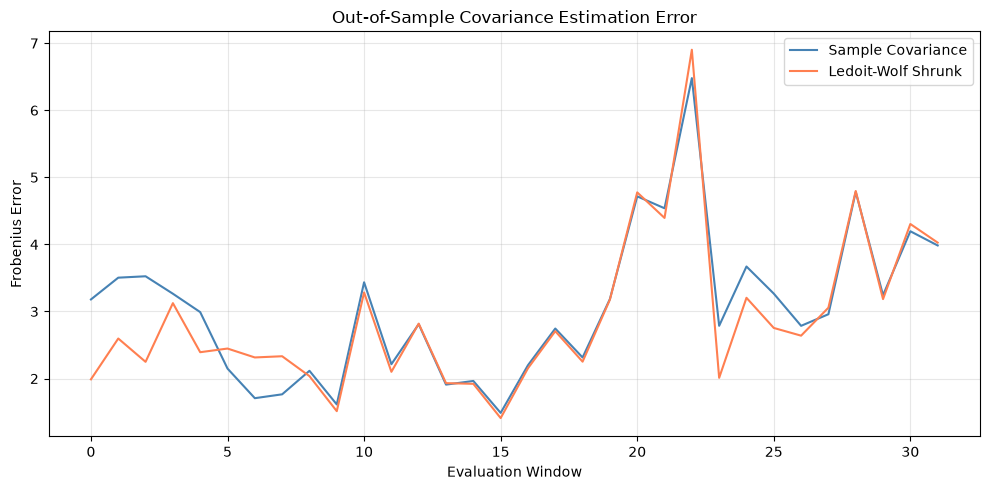

In [7]:
"""
==================================
Out-of-sample comparison: sample vs. shrunk covariance
==================================

We use a rolling window: estimate covariance on trailing 60 months,
compute portfolio variance forecast, compare to realized variance
over the next month. Lower Frobenius error = better estimator.
"""
window = 60
dates = df_returns.index
errors_sample = []
errors_shrunk = []

for i in range(window, len(dates) - 1, 6):  # Every 6 months for speed
    train = df_returns.iloc[i-window:i].dropna(axis=1, thresh=window//2).dropna()
    test = df_returns.iloc[i:i+1][train.columns]
    
    if test.shape[1] < 20:
        continue
    
    # Shrunk covariance (recompute on this window)
    lw = ledoit_wolf_shrinkage(df_returns.iloc[i-window:i])
    S_shrunk = lw['cov_shrunk']
    
    # Find common tickers between train and the shrunk estimator
    common = train.columns.intersection(lw['tickers'])
    if len(common) < 20:
        continue
    
    # Sample covariance on common tickers only
    train_common = train[common]
    S_sample = np.cov(train_common, rowvar=False, ddof=1)
    
    # Shrunk covariance aligned to common tickers
    S_shrunk_aligned = pd.DataFrame(
        S_shrunk, index=lw['tickers'], columns=lw['tickers']
    ).loc[common, common].values
    
    # Realized covariance (outer product of next month's returns) on common tickers
    test_common = test[common]
    realized = np.outer(test_common.values[0], test_common.values[0])
    
    err_sample = np.linalg.norm(S_sample - realized, 'fro')
    err_shrunk = np.linalg.norm(S_shrunk_aligned - realized, 'fro')
    
    errors_sample.append(err_sample)
    errors_shrunk.append(err_shrunk)

print(f"Number of evaluation windows: {len(errors_sample)}")
print(f"Mean Frobenius error (sample): {np.mean(errors_sample):.4f}")
print(f"Mean Frobenius error (shrunk): {np.mean(errors_shrunk):.4f}")
print(f"Improvement: {(1 - np.mean(errors_shrunk)/np.mean(errors_sample))*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(errors_sample, label='Sample Covariance', color='steelblue')
ax.plot(errors_shrunk, label='Ledoit-Wolf Shrunk', color='coral')
ax.set_xlabel('Evaluation Window')
ax.set_ylabel('Frobenius Error')
ax.set_title('Out-of-Sample Covariance Estimation Error')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/ledoit_wolf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Portfolio Variance Decomposition

Given a portfolio weight vector $w \in \mathbb{R}^N$, split $\Sigma$ into its top-$k$ eigendirections and the orthogonal complement:
$$\Sigma = \underbrace{\mathbf{B}\Sigma_f \mathbf{B}^\top}_{\text{factor subspace}} + \underbrace{(\Sigma - \mathbf{B}\Sigma_f \mathbf{B}^\top)}_{\text{orthogonal complement}},$$
where $\mathbf{B} \in \mathbb{R}^{N \times k}$ holds the top-$k$ eigenvectors and $\Sigma_f = \text{diag}(\lambda_1, \dots, \lambda_k)$ the top-$k$ eigenvalues. The portfolio variance decomposes **exactly**:

$$w^\top \Sigma w = \underbrace{w^\top \mathbf{B} \Sigma_f \mathbf{B}^\top w}_{\text{systematic}} + \underbrace{w^\top (\Sigma - \mathbf{B}\Sigma_f \mathbf{B}^\top) w}_{\text{idiosyncratic}}.$$

**Geometrically:** the systematic term is $\|\Sigma_f^{1/2} \mathbf{B}^\top w\|^2$ — the squared norm of the weight vector *projected into the factor subspace* (spanned by the top-$k$ eigenvectors), scaled by the eigenvalues. The idiosyncratic term is the variance living in the orthogonal complement — risk not captured by the top-$k$ common factors. (A strict *factor model* would assume this residual is diagonal, i.e. uncorrelated idiosyncratic risk; we keep the full residual so the split sums to 100% of total variance.)

The number of factors $k$ comes from the Marchenko–Pastur analysis above.

In [8]:
"""
==================================
Reconstruct the long portfolio weights at the last rebalance
==================================
"""
df_signal = pd.read_csv('../data/processed/momentum_signal.csv', index_col=0, parse_dates=True)

# Take the last rebalance date
last_date = df_signal.index[-2]  # -2 because we trade t+1
scores = df_signal.loc[last_date].dropna()

n_long = max(int(len(scores) * 0.1), 1)
long_tickers = scores.sort_values(ascending=False).head(n_long).index.tolist()

# Equal-weighted weights
w = pd.Series(1.0 / len(long_tickers), index=long_tickers)

print(f"Last rebalance: {last_date}")
print(f"Number of long holdings: {len(long_tickers)}")
print(f"Weight per stock: {w.iloc[0]:.4f}")

Last rebalance: 2025-11-30 00:00:00
Number of long holdings: 49
Weight per stock: 0.0204


Using top 9 PCs as statistical factors

### Portfolio Variance Decomposition

Total portfolio variance:      0.001336
Systematic (factor) variance:  0.001212  (90.7%)
Idiosyncratic variance:        0.000124  (9.3%)


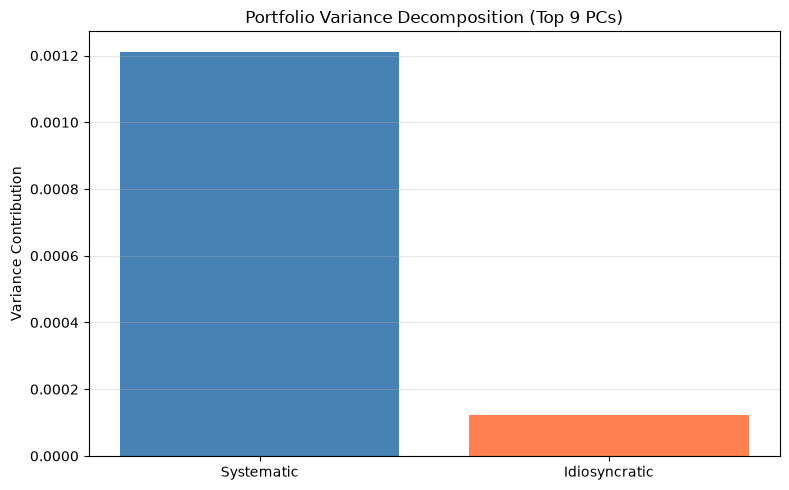

In [9]:
"""
==================================
Variance decomposition using top-k PCs as factors
==================================
"""
# Align weights to PCA tickers
pca_tickers = pca_result['tickers']
w_aligned = w.reindex(pca_tickers).fillna(0).values

cov = pca_result['cov']
eigenvalues = pca_result['eigenvalues']
eigenvectors = pca_result['eigenvectors']

k = n_signal  # Number of signal PCs
print(f"Using top {k} PCs as statistical factors")

# Factor loadings: B = eigenvectors (N x k)
B = eigenvectors[:, :k]

# Factor covariance: diagonal matrix of top-k eigenvalues
Sigma_f = np.diag(eigenvalues[:k])

# Idiosyncratic variance: residual variance per stock
# D = diag(Sigma - B Sigma_f B^T)
Sigma_factor = B @ Sigma_f @ B.T

# Portfolio variance
total_var = w_aligned @ cov @ w_aligned
systematic_var = w_aligned @ Sigma_factor @ w_aligned
# Idiosyncratic = variance in the orthogonal complement of the top-k factor
# subspace. Equals total - systematic by construction, so the split sums to 100%.
idiosyncratic_var = total_var - systematic_var

print(f"\n### Portfolio Variance Decomposition\n")
print(f"Total portfolio variance:      {total_var:.6f}")
print(f"Systematic (factor) variance:  {systematic_var:.6f}  ({systematic_var/total_var*100:.1f}%)")
print(f"Idiosyncratic variance:        {idiosyncratic_var:.6f}  ({idiosyncratic_var/total_var*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Systematic', 'Idiosyncratic'], [systematic_var, idiosyncratic_var], 
       color=['steelblue', 'coral'])
ax.set_ylabel('Variance Contribution')
ax.set_title(f'Portfolio Variance Decomposition (Top {k} PCs)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/variance_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

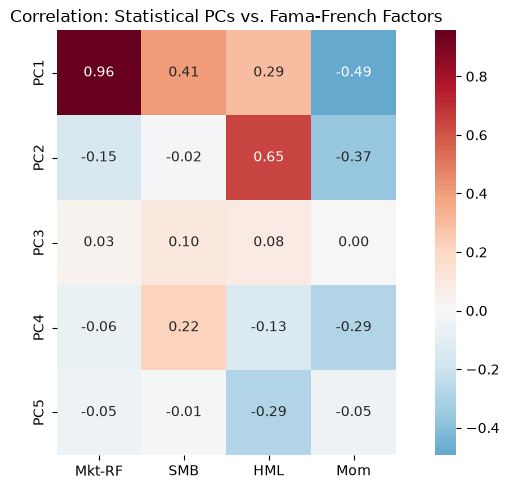

,Mkt-RF,SMB,HML,Mom
PC1,0.957,0.407,0.292,-0.493
PC2,-0.155,-0.022,0.646,-0.366
PC3,0.031,0.104,0.085,0.004
PC4,-0.059,0.221,-0.134,-0.288
PC5,-0.052,-0.012,-0.286,-0.048


In [10]:
"""
==================================
Compare statistical factors to known FF factors
==================================
"""
df_ff = pd.read_csv('../data/raw/ff_factors.csv', index_col=0, parse_dates=True)

# Project top PCs onto FF factor returns
# Align dates: df_returns has month-end, df_ff has month-start
# Convert to month-end timestamps, then normalize midnight for exact matching
common_dates = df_returns.index.to_period('M').intersection(
    df_ff.index.to_period('M')
).to_timestamp(how='end').normalize()
df_ret_aligned = df_returns.loc[common_dates, pca_tickers].dropna()
df_ff_aligned = df_ff.copy()
df_ff_aligned.index = df_ff_aligned.index.to_period('M').to_timestamp(how='end').normalize()
df_ff_aligned = df_ff_aligned.loc[df_ret_aligned.index]

# Compute PC returns: PC_i = eigenvector_i^T @ returns
pc_returns = pd.DataFrame(
    df_ret_aligned.values @ eigenvectors[:, :5],
    index=df_ret_aligned.index,
    columns=[f'PC{i+1}' for i in range(5)]
)

# Correlate PCs with FF factors
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'Mom']
df_corr = pd.DataFrame(index=[f'PC{i+1}' for i in range(5)], columns=factor_cols)

for pc in pc_returns.columns:
    for ff in factor_cols:
        mask = pc_returns[pc].notna() & df_ff_aligned[ff].notna()
        df_corr.loc[pc, ff] = pc_returns.loc[mask, pc].corr(df_ff_aligned.loc[mask, ff])

df_corr = df_corr.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Correlation: Statistical PCs vs. Fama-French Factors')

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/pc_vs_ff_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_corr.round(3))

In [11]:
"""
==================================
Save risk decomposition results
==================================
"""
decomp_results = pd.DataFrame({
    'component': ['total', 'systematic', 'idiosyncratic'],
    'variance': [total_var, systematic_var, idiosyncratic_var],
    'pct': [100, systematic_var/total_var*100, idiosyncratic_var/total_var*100]
})
decomp_results.to_csv('../data/processed/variance_decomposition.csv', index=False)

pd.DataFrame({
    'eigenvalue': eigenvalues[:50],
    'explained_pct': pca_result['explained_ratio'][:50] * 100
}).to_csv('../data/processed/pca_spectrum.csv', index=False)

print("Saved:")
print("  - variance_decomposition.csv")
print("  - pca_spectrum.csv")

Saved:
  - variance_decomposition.csv
  - pca_spectrum.csv


## Conclusion

We now have a complete picture of where the portfolio's risk comes from:

- The **Marchenko–Pastur analysis** tells us how many eigenvalues of $\Sigma$ exceed the random-matrix noise threshold — i.e., how many statistically significant factors drive the cross-section.
- The **Ledoit–Wolf shrinkage** shows that the sample covariance is noisy enough to benefit from regularization (a convex combination with a structured target).
- The **variance decomposition** splits the quadratic form $w^\top \Sigma w$ into the factor subspace (systematic risk) and its orthogonal complement (idiosyncratic risk).

The momentum long-only portfolio's risk is overwhelmingly systematic (driven by common market and factor exposures), with a small idiosyncratic component — consistent with a diversified top-decile portfolio of ~50 stocks. The Fama–French alpha of 5.95% (t = 3.95) from notebook 04 is the component of return *orthogonal* to these systematic factors.

The next notebook (06) uses the truncated-SVD factor structure to generate synthetic markets for stress testing — asking whether the alpha is genuine skill or luck.